In [1]:
import numpy as np
import os
import scipy.io

In [2]:
import tarfile
import numpy as np 

In [3]:
labelsn = scipy.io.loadmat("imagelabels.mat")
labelsn = labelsn["labels"]
labelsn = labelsn[0]
for i in range(len(labelsn)):
  labelsn[i] = labelsn[i] - 1

In [4]:

import cv2
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split

Instructions for updating:
non-resource variables are not supported in the long term


In [5]:
train_x = []
train_y = []
dir = "flowers/"
for imgs in os.listdir(dir):
    imgnum = int(imgs[7:11])-1
    train_y.append(labelsn[imgnum])
    image = cv2.imread(os.path.join(dir, imgs))
    new_size = cv2.resize(image, (150,150))
    normalized_image = cv2.normalize(new_size, None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F)
    train_x.append(normalized_image)
train_x = np.array(train_x)

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
trainx, valx, trainy, valy = train_test_split(train_x, train_y, test_size=0.25, random_state=10)

In [8]:
trainingimages= trainx/255.0
testingimages=valx/255.0

trainingimages = trainx.reshape((6141, 150, 150, 3))
valx = valx.reshape((2048,150,150,3))
print('Shape of Training Data: {}'.format(trainx.shape))
print('No. of training examples: {}'.format(len(trainy)))
print('Shape of Testing Data: {}'.format(valx.shape))
print('No. of testing examples: {}'.format(len(valy)))

Shape of Training Data: (6141, 150, 150, 3)
No. of training examples: 6141
Shape of Testing Data: (2048, 150, 150, 3)
No. of testing examples: 2048


In [9]:
trainy = to_categorical(trainy)
valy = to_categorical(valy)
print(valy.shape)

(2048, 102)


In [10]:
from keras import backend as K
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam,SGD,Adagrad,Adadelta,RMSprop
from keras.utils import to_categorical

In [11]:
from keras.layers import Dropout, Flatten,Activation
from keras.layers import Conv2D, MaxPooling2D, BatchNormalization

In [25]:
img_width, img_height = 150, 150

In [26]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(102, activation='softmax')
])


In [27]:
model.compile(optimizer=Adam(lr=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [28]:
batchSize=64
ep=35
model.fit(trainx,trainy,batch_size=batchSize,epochs=ep,validation_split=.15)

Train on 5219 samples, validate on 922 samples
Epoch 1/35
5219/5219 [==============================] - 183s 35ms/sample - loss: 4.5202 - acc: 0.0337 - val_loss: 4.3405 - val_acc: 0.0792
Epoch 2/35
5219/5219 [==============================] - 182s 35ms/sample - loss: 4.2974 - acc: 0.0567 - val_loss: 4.1123 - val_acc: 0.1020
Epoch 3/35
5219/5219 [==============================] - 186s 36ms/sample - loss: 4.0884 - acc: 0.0931 - val_loss: 3.9027 - val_acc: 0.1269
Epoch 4/35
5219/5219 [==============================] - 183s 35ms/sample - loss: 3.8941 - acc: 0.1257 - val_loss: 3.7156 - val_acc: 0.1605
Epoch 5/35
5219/5219 [==============================] - 183s 35ms/sample - loss: 3.6824 - acc: 0.1585 - val_loss: 3.5209 - val_acc: 0.2028
Epoch 6/35
5219/5219 [==============================] - 186s 36ms/sample - loss: 3.4731 - acc: 0.1922 - val_loss: 3.3621 - val_acc: 0.2321
Epoch 7/35
5219/5219 [==============================] - 188s 36ms/sample - loss: 3.2873 - acc: 0.2324 - val_loss: 3.247

In [29]:
model.evaluate(valx,valy)

[2.713267108425498, 0.4165039]

In [30]:
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

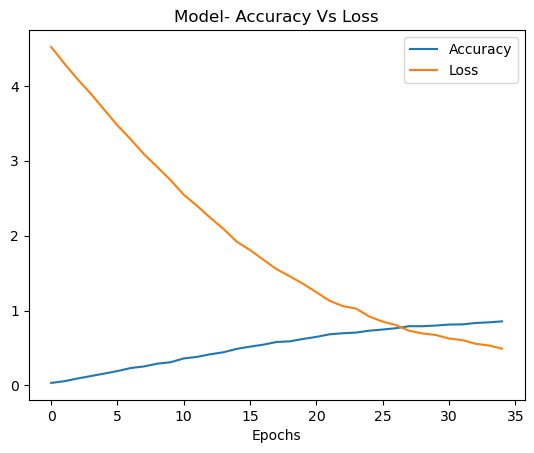

In [31]:
plt.plot(range(len(model.history.history['acc'])),model.history.history['acc'])
plt.plot(range(len(model.history.history['loss'])),model.history.history['loss'])
plt.title('Model- Accuracy Vs Loss')
plt.xlabel('Epochs')
plt.legend(['Accuracy', 'Loss'])
plt.show()

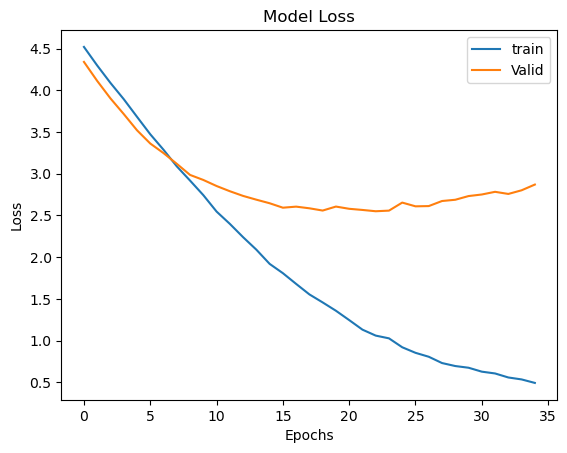

In [32]:
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['train', 'Valid'])
plt.show()

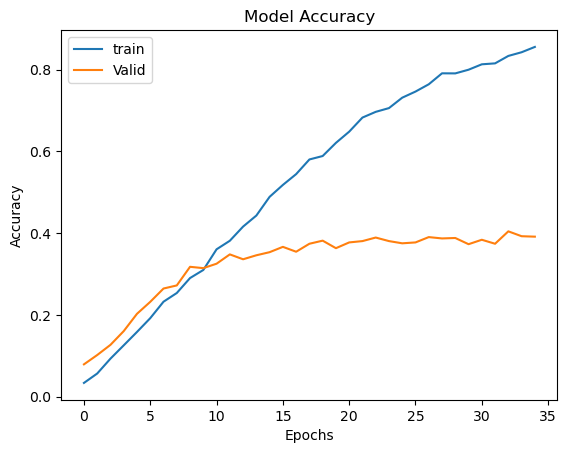

In [33]:
plt.plot(model.history.history['acc'])
plt.plot(model.history.history['val_acc'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'Valid'])
plt.show()

In [34]:
pred=model.predict(valx)
print("Predicted Probabilities -\n",pred[:4])
pred_digits=np.argmax(pred,axis=1)
print("\nPredicted Class [Highest Prob] -",pred_digits[:4])

C:\Users\blaks\anaconda3\lib\site-packages\keras\engine\training_v1.py:2359: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,


Predicted Probabilities -
 [[2.21118404e-04 1.23342508e-02 1.73370505e-03 7.71530031e-05
  5.26795688e-04 2.65023817e-04 1.67237478e-04 1.56394637e-03
  2.93111050e-04 7.95327742e-06 1.19424276e-02 1.21651089e-03
  4.12302237e-04 2.22862989e-04 2.16824737e-05 2.65721046e-05
  2.39905276e-04 1.24067785e-02 4.65500052e-04 1.03291217e-03
  1.13886403e-04 2.31888285e-03 3.75257828e-03 4.38592397e-05
  5.90751763e-04 7.56057989e-06 5.10430436e-05 3.49852984e-04
  4.14107461e-04 1.11119688e-01 5.31358272e-03 6.32786844e-03
  2.89527990e-04 3.80772515e-04 2.38536577e-05 1.97961531e-03
  2.68700533e-03 1.08400022e-03 4.74008324e-04 5.72078163e-03
  2.10617320e-03 1.51381351e-03 2.20768765e-01 1.30938704e-03
  3.63127887e-02 7.19094969e-05 1.94851978e-04 3.98563541e-04
  1.51857283e-04 4.69403631e-06 5.16298339e-02 4.54864028e-04
  6.88693998e-03 2.34352920e-05 3.04380606e-04 8.95481753e-06
  1.03859184e-03 4.53914370e-04 1.75091718e-05 1.99028018e-05
  3.83614206e-05 4.51523578e-04 9.53260769e

In [35]:
i=0
prop_class=[]
mis_class=[]

for i in range(len(valy)):
    if(np.argmax(valy[i])==pred_digits[i]):
        prop_class.append(i)
    if(len(prop_class)==8):
        break

i=0
for i in range(len(valy)):
    if(not np.argmax(valy[i])==pred_digits[i]):
        mis_class.append(i)
    if(len(mis_class)==8):
        break

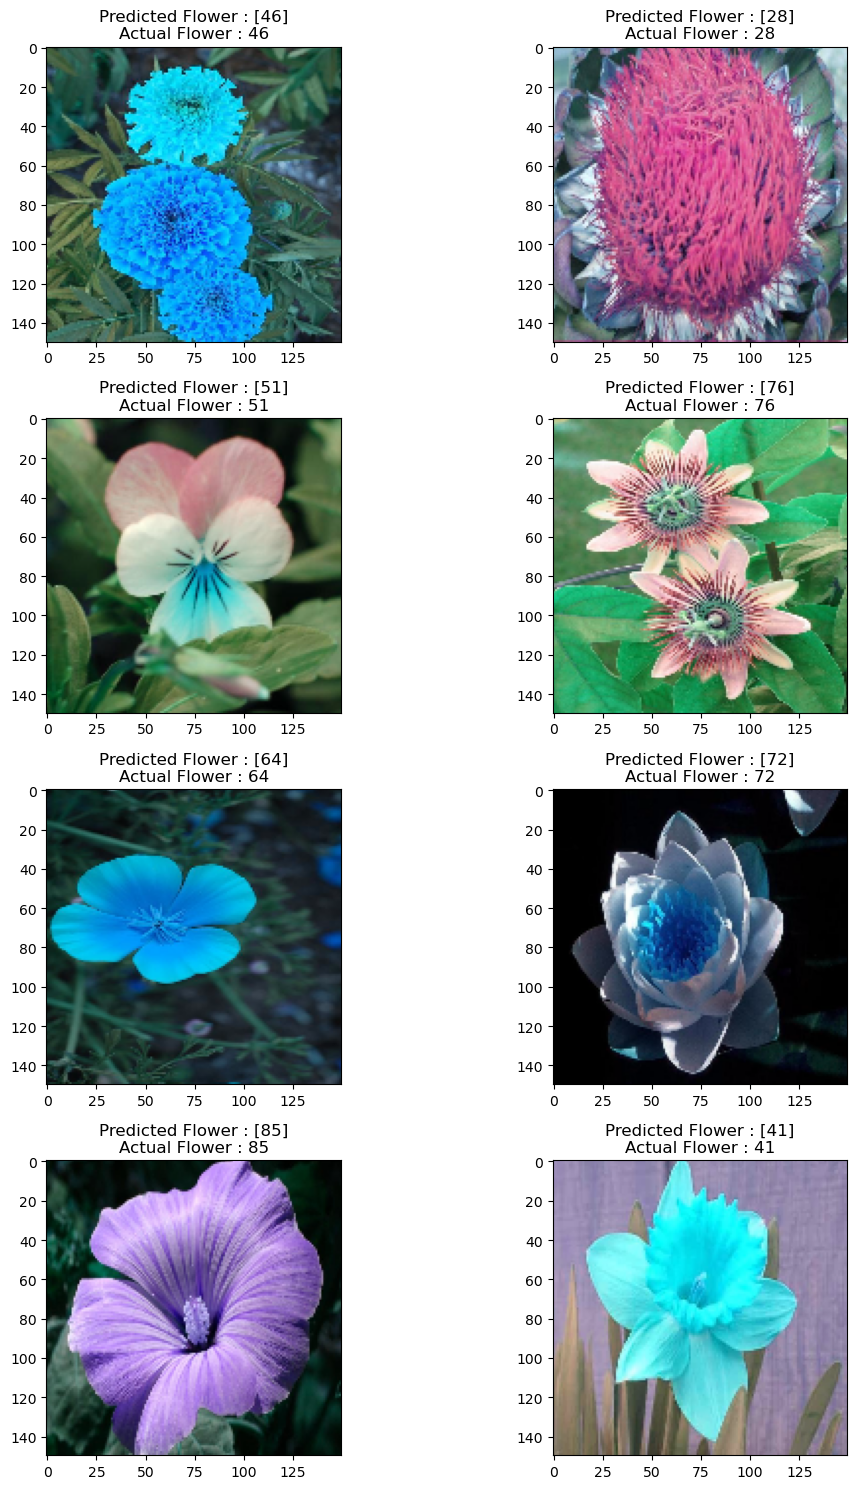

In [36]:
import warnings
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()


warnings.filterwarnings('always')
warnings.filterwarnings('ignore')

count=0
fig,ax=plt.subplots(4,2)
fig.set_size_inches(15,15)
for i in range (4):
    for j in range (2):
        ax[i,j].imshow(valx[prop_class[count]])
        ax[i,j].set_title("Predicted Flower : "+str([pred_digits[prop_class[count]]])+"\n"+"Actual Flower : "+str(np.argmax([valy[prop_class[count]]])))
        plt.tight_layout()
        count+=1